# Expert 1: Tire Dynamics - GMM Training

## Objective: Train Gaussian Mixture Model for tire anomaly detection

This notebook trains a GMM to detect tire-related anomalies:
- Overheating
- Uneven wear
- Pressure loss
- Excessive slip

**Input Features (20)**: TireTemp, TireWear, TirePressure, SlipRatio, SlipAngle (4 wheels)

**Output**: Trained GMM model + anomaly threshold

---

## Section 0: Imports and Configuration

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pickle
import json

SEED = 42
np.random.seed(SEED)

In [20]:
# Configuration
ROOT = Path.cwd().parents[1]
DATA_DIR = ROOT / 'data' / 'processed' / 'MoE-anomaly'
SPLITS_DIR = DATA_DIR / 'splits'
SCALERS_DIR = DATA_DIR / 'scalers'
FIGS_DIR = DATA_DIR / 'figs'
MODELS_DIR = ROOT / 'models' / 'anomaly-detection'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Expert name
EXPERT_NAME = 'expert1_tire'

print(f"Expert: {EXPERT_NAME}")
print(f"Data directory: {SPLITS_DIR}")
print(f"Models directory: {MODELS_DIR}")

Expert: expert1_tire
Data directory: c:\Users\usuario\Documents\F1_AC_Digital_Twin\data\processed\MoE-anomaly\splits
Models directory: c:\Users\usuario\Documents\F1_AC_Digital_Twin\models\anomaly-detection


---

## Section 1: Load Processed Data

In [21]:
def load_expert_data(expert_name, splits_dir):
    """
    Load train/val/test data for an expert.
    """
    splits = {}
    for split_name in ['train', 'val', 'test']:
        filepath = splits_dir / f"{expert_name}_{split_name}.csv"
        splits[split_name] = pd.read_csv(filepath)
        print(f"Loaded {split_name}: {len(splits[split_name])} samples")
    
    return splits

# Load data
data_splits = load_expert_data(EXPERT_NAME, SPLITS_DIR)

# Get feature columns (exclude metadata)
META_COLS = ['Timestamp', 'CompletedLaps', 'DistanceTraveled_m', 'CurrentSectorIndex', 'IsInPit']
FEATURE_COLS = [col for col in data_splits['train'].columns if col not in META_COLS]

print(f"\nFeatures: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Loaded train: 46260 samples
Loaded val: 9781 samples
Loaded test: 10084 samples

Features: 20
['TireTemp_FL_Avg', 'TireTemp_FR_Avg', 'TireTemp_RL_Avg', 'TireTemp_RR_Avg', 'TireWear_FL', 'TireWear_FR', 'TireWear_RL', 'TireWear_RR', 'TirePressure_FL', 'TirePressure_FR', 'TirePressure_RL', 'TirePressure_RR', 'SlipRatio_FL', 'SlipRatio_FR', 'SlipRatio_RL', 'SlipRatio_RR', 'SlipAngle_FL', 'SlipAngle_FR', 'SlipAngle_RL', 'SlipAngle_RR']


---

## Section 2: Exploratory Data Analysis

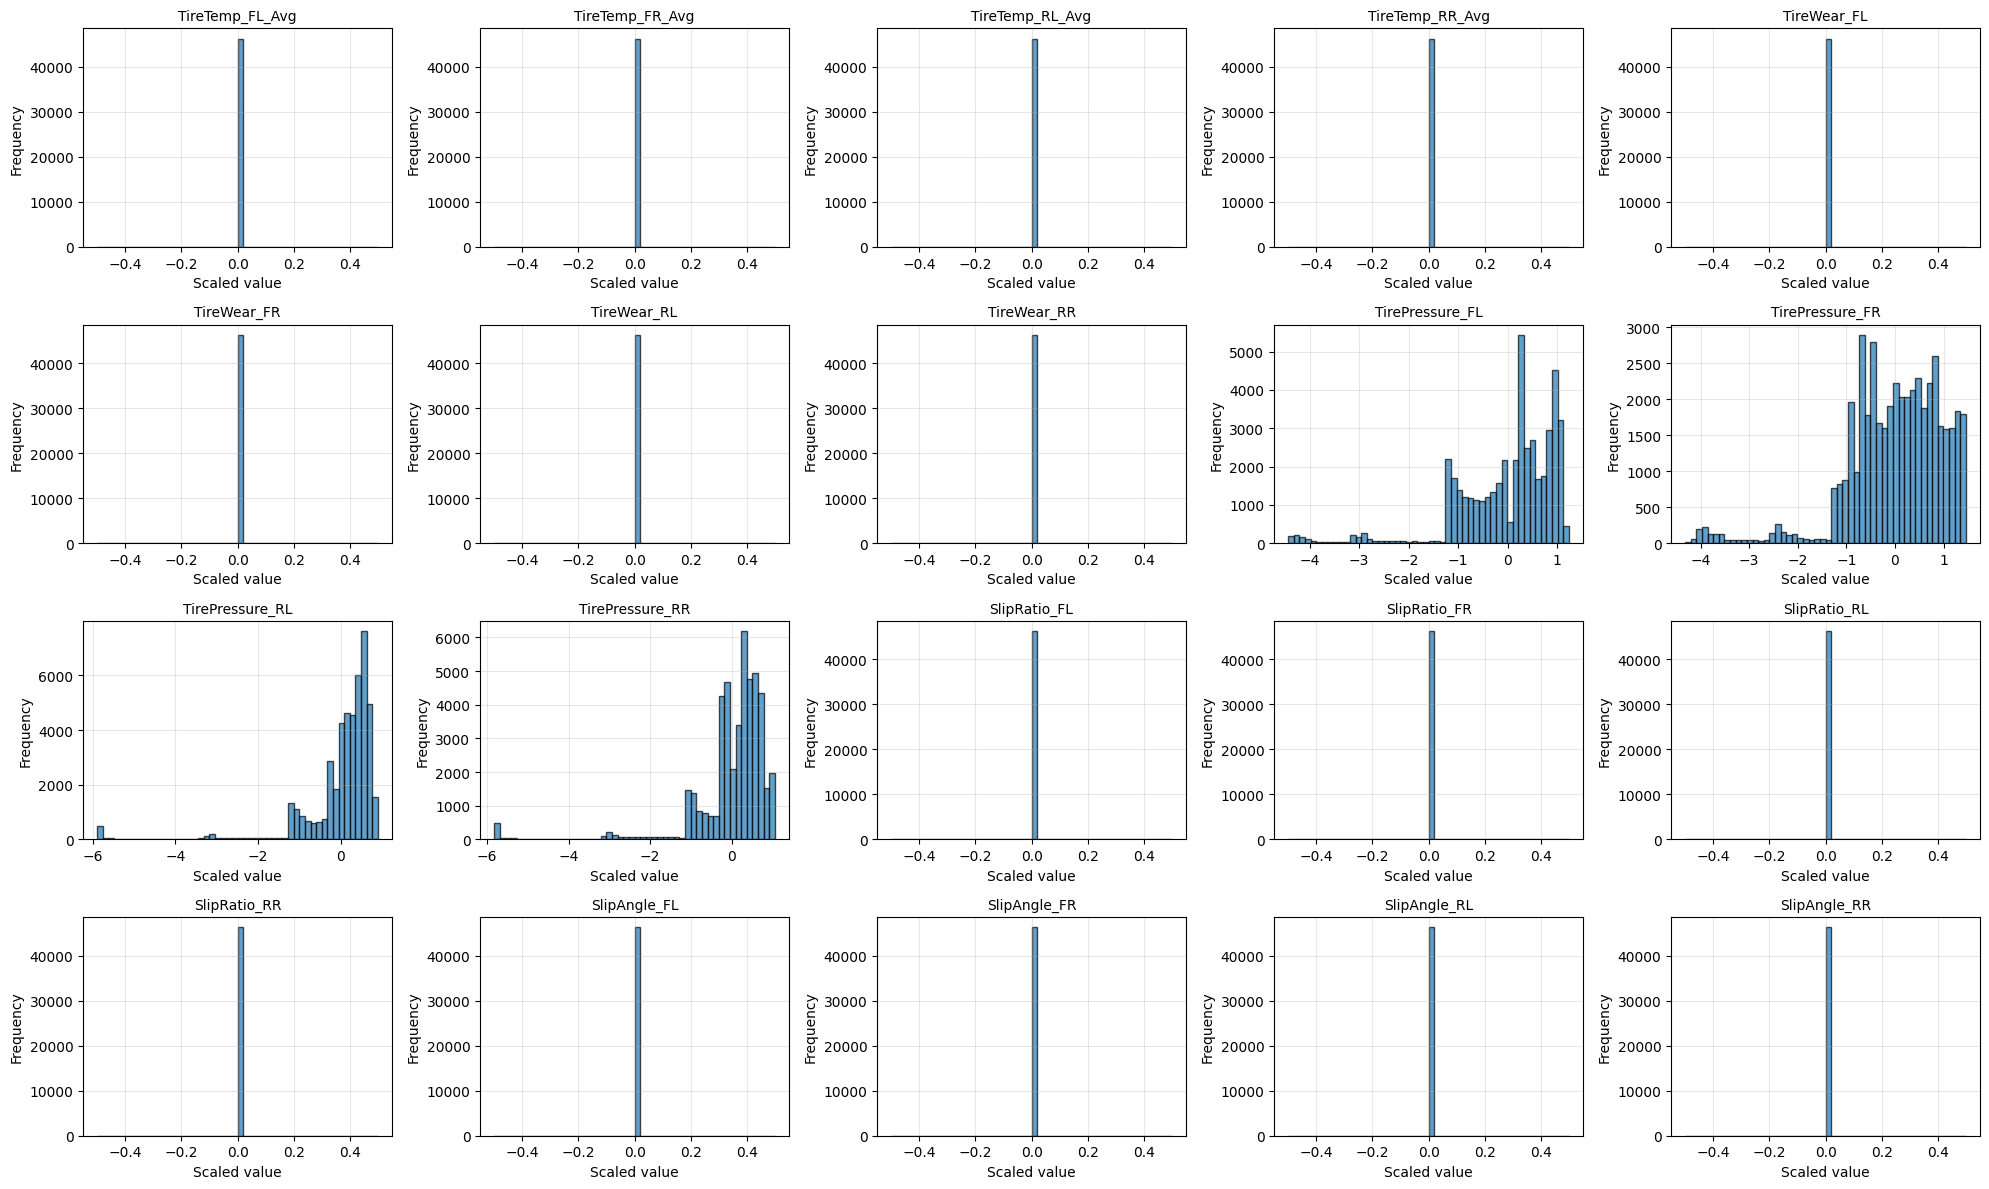

In [22]:
# Plot feature distributions
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
axes = axes.flatten()

train_data = data_splits['train'][FEATURE_COLS]

for i, feature in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.hist(train_data[feature], bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel('Scaled value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_distributions.png', dpi=150)
plt.show()


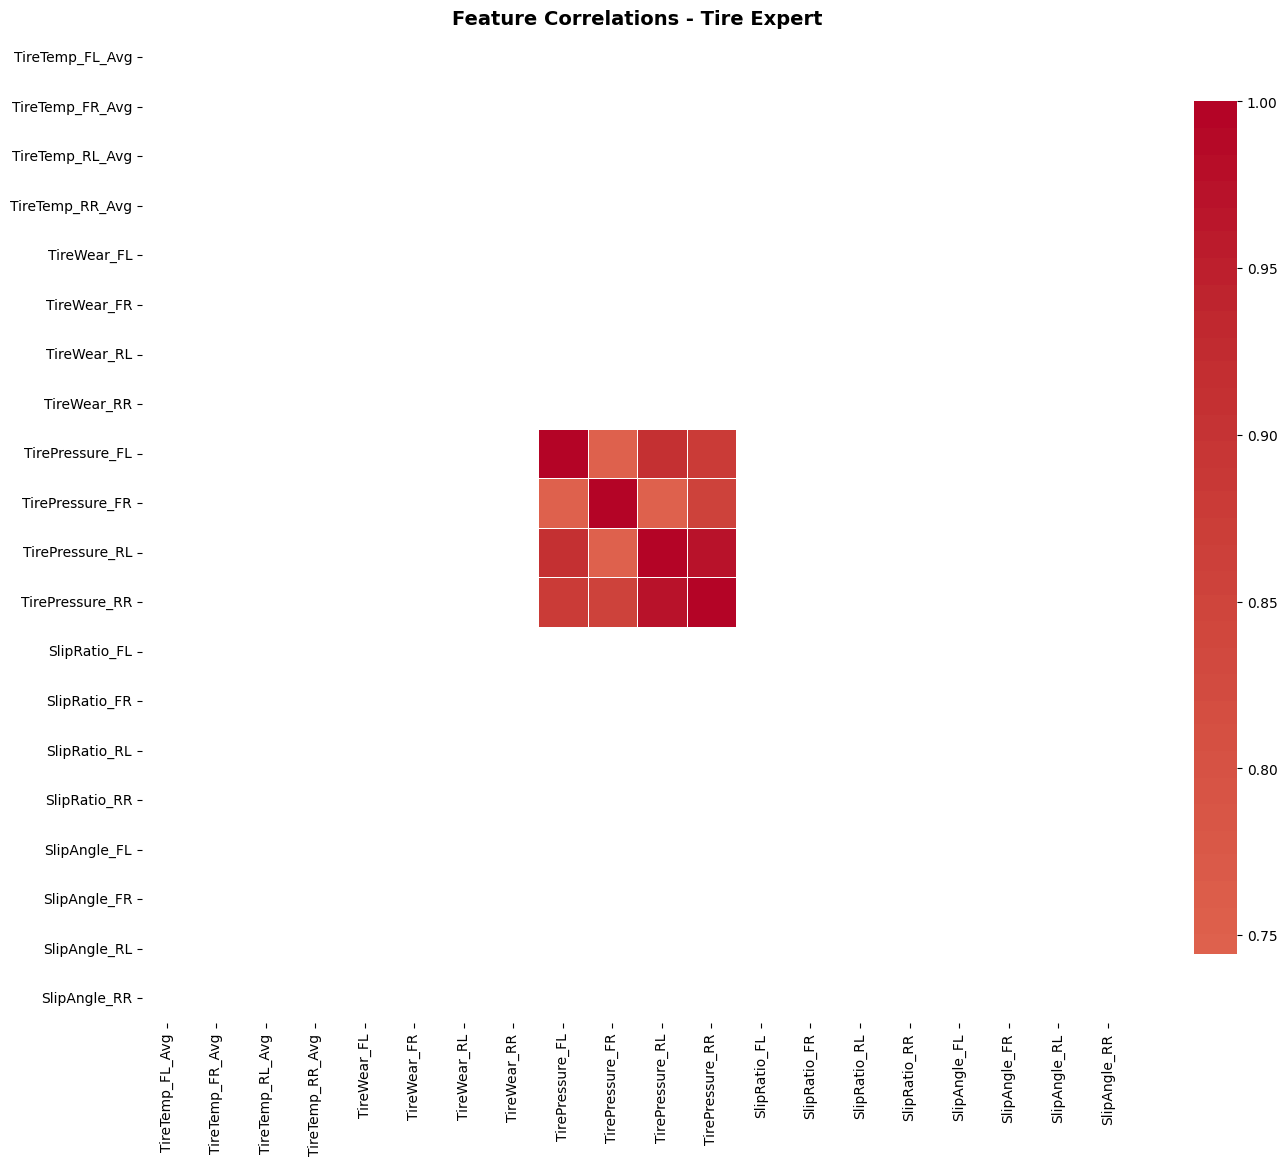

In [23]:
# Correlation heatmap
import seaborn as sns

plt.figure(figsize=(14, 12))
corr = train_data.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlations - Tire Expert', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_correlation.png', dpi=150)
plt.show()

---

## Section 3: GMM Training with Hyperparameter Tuning

In [24]:
def train_gmm_with_tuning(X_train, X_val, n_components_range=(2, 6)):
    """
    Train GMM models with different number of components.
    Select best based on BIC/AIC on validation set.
    """
    results = []
    
    for n_components in range(n_components_range[0], n_components_range[1]):
        print(f"\nTraining GMM with {n_components} components...")
        
        # Train model
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type='full',
            random_state=SEED,
            max_iter=200,
            n_init=10
        )
        
        gmm.fit(X_train)
        
        # Compute metrics
        train_bic = gmm.bic(X_train)
        train_aic = gmm.aic(X_train)
        val_bic = gmm.bic(X_val)
        val_aic = gmm.aic(X_val)
        
        # Log likelihood
        train_ll = gmm.score(X_train)
        val_ll = gmm.score(X_val)
        
        results.append({
            'n_components': n_components,
            'model': gmm,
            'train_bic': train_bic,
            'train_aic': train_aic,
            'val_bic': val_bic,
            'val_aic': val_aic,
            'train_ll': train_ll,
            'val_ll': val_ll,
            'converged': gmm.converged_
        })
        
        print(f"  Val BIC: {val_bic:.2f}")
        print(f"  Val AIC: {val_aic:.2f}")
        print(f"  Converged: {gmm.converged_}")
    
    return results

# Extract feature data
X_train = data_splits['train'][FEATURE_COLS].values
X_val = data_splits['val'][FEATURE_COLS].values
X_test = data_splits['test'][FEATURE_COLS].values

# Train models
gmm_results = train_gmm_with_tuning(X_train, X_val, n_components_range=(2, 6))


Training GMM with 2 components...
  Val BIC: -1853635.33
  Val AIC: -1856949.09
  Converged: True

Training GMM with 3 components...
  Val BIC: -1871705.20
  Val AIC: -1876679.43
  Converged: True

Training GMM with 4 components...
  Val BIC: -1885455.72
  Val AIC: -1892090.43
  Converged: True

Training GMM with 5 components...
  Val BIC: -1891223.96
  Val AIC: -1899519.14
  Converged: True


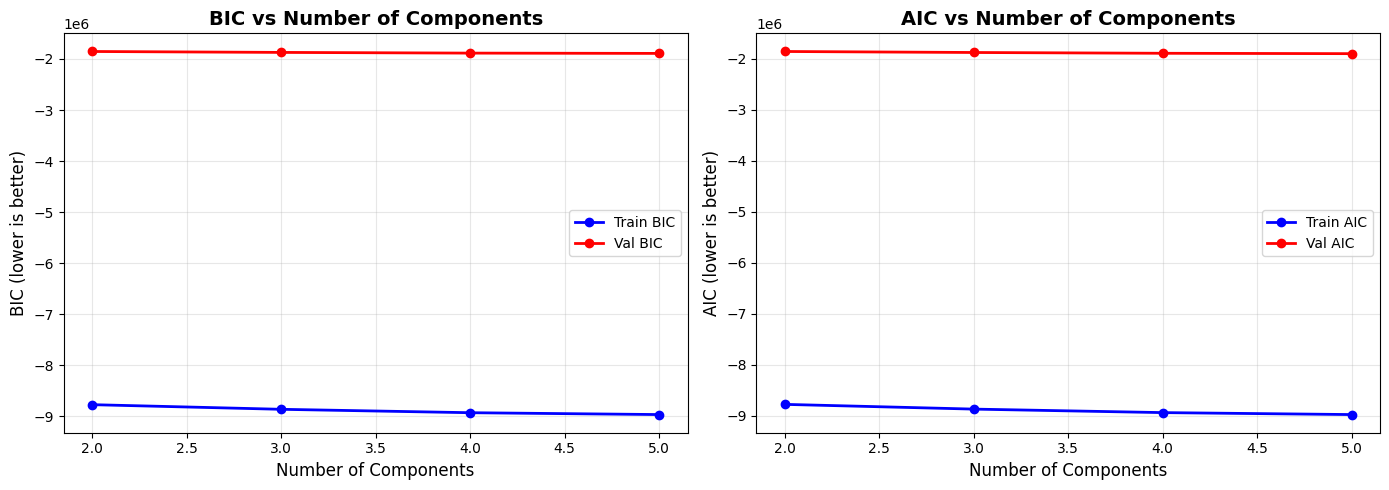

In [25]:
# Plot BIC/AIC curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_comps = [r['n_components'] for r in gmm_results]
train_bics = [r['train_bic'] for r in gmm_results]
val_bics = [r['val_bic'] for r in gmm_results]
train_aics = [r['train_aic'] for r in gmm_results]
val_aics = [r['val_aic'] for r in gmm_results]

# BIC plot
ax1.plot(n_comps, train_bics, 'b-o', label='Train BIC', linewidth=2)
ax1.plot(n_comps, val_bics, 'r-o', label='Val BIC', linewidth=2)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('BIC (lower is better)', fontsize=12)
ax1.set_title('BIC vs Number of Components', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AIC plot
ax2.plot(n_comps, train_aics, 'b-o', label='Train AIC', linewidth=2)
ax2.plot(n_comps, val_aics, 'r-o', label='Val AIC', linewidth=2)
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('AIC (lower is better)', fontsize=12)
ax2.set_title('AIC vs Number of Components', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_model_selection.png', dpi=150)
plt.show()

In [26]:
# Select best model based on validation BIC
best_result = min(gmm_results, key=lambda x: x['val_bic'])
best_gmm = best_result['model']
best_n_components = best_result['n_components']

print("=" * 60)
print("BEST MODEL SELECTED")
print("=" * 60)
print(f"Number of components: {best_n_components}")
print(f"Validation BIC: {best_result['val_bic']:.2f}")
print(f"Validation AIC: {best_result['val_aic']:.2f}")
print(f"Converged: {best_result['converged']}")

BEST MODEL SELECTED
Number of components: 5
Validation BIC: -1891223.96
Validation AIC: -1899519.14
Converged: True


---

## Section 4: Anomaly Score Calculation

In [27]:
def compute_anomaly_scores(gmm, X):
    """
    Compute anomaly scores as negative log-likelihood.
    Higher score = more anomalous.
    """
    log_likelihood = gmm.score_samples(X)
    anomaly_scores = -log_likelihood
    return anomaly_scores

# Compute scores for all splits
scores = {}
for split_name, split_data in data_splits.items():
    X = split_data[FEATURE_COLS].values
    scores[split_name] = compute_anomaly_scores(best_gmm, X)
    print(f"{split_name} - Mean score: {scores[split_name].mean():.3f}, Std: {scores[split_name].std():.3f}")

train - Mean score: -97.028, Std: 2.049
val - Mean score: -97.220, Std: 2.029
test - Mean score: -96.796, Std: 2.253


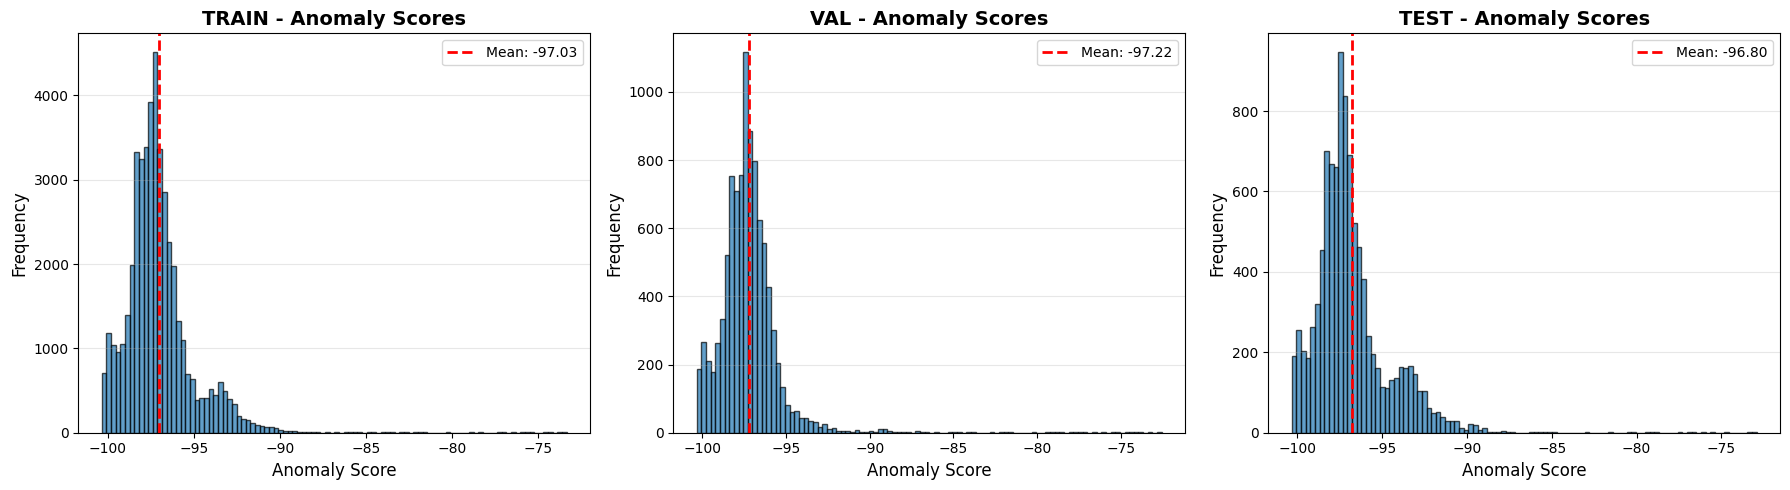

In [28]:
# Plot anomaly score distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (split_name, split_scores) in zip(axes, scores.items()):
    ax.hist(split_scores, bins=100, alpha=0.7, edgecolor='black')
    ax.axvline(split_scores.mean(), color='r', linestyle='--', linewidth=2, 
               label=f'Mean: {split_scores.mean():.2f}')
    ax.set_xlabel('Anomaly Score', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{split_name.upper()} - Anomaly Scores', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_anomaly_scores.png', dpi=150)
plt.show()

---

## Section 5: Threshold Selection

In [29]:
# Define threshold as 95th percentile of training scores
PERCENTILE = 95
threshold = np.percentile(scores['train'], PERCENTILE)

print(f"Anomaly threshold ({PERCENTILE}th percentile): {threshold:.3f}")

# Calculate anomaly rates per split
for split_name, split_scores in scores.items():
    anomaly_rate = (split_scores > threshold).sum() / len(split_scores) * 100
    print(f"{split_name}: {anomaly_rate:.2f}% anomalies")

Anomaly threshold (95th percentile): -93.246
train: 5.00% anomalies
val: 2.17% anomalies
test: 7.70% anomalies


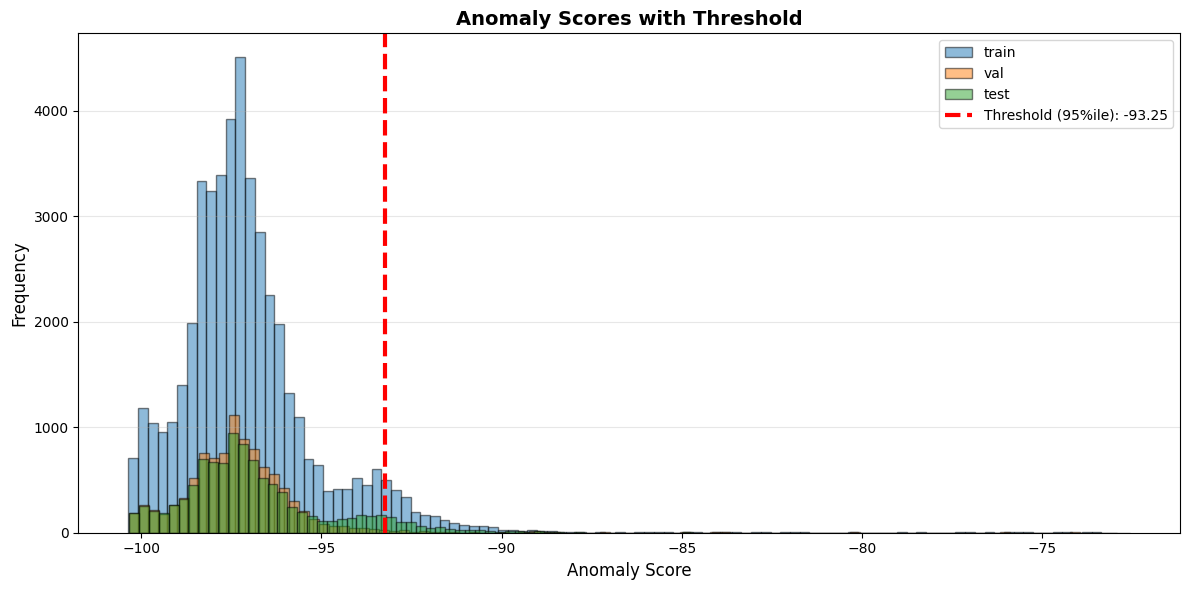

In [30]:
# Plot threshold on distributions
fig, ax = plt.subplots(figsize=(12, 6))

for split_name, split_scores in scores.items():
    ax.hist(split_scores, bins=100, alpha=0.5, label=split_name, edgecolor='black')

ax.axvline(threshold, color='r', linestyle='--', linewidth=3, 
           label=f'Threshold ({PERCENTILE}%ile): {threshold:.2f}')
ax.set_xlabel('Anomaly Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Anomaly Scores with Threshold', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGS_DIR / f'{EXPERT_NAME}_threshold.png', dpi=150)
plt.show()

---

## Section 6: Model Interpretation

In [31]:
# Analyze GMM components
print("=" * 60)
print("GMM COMPONENT ANALYSIS")
print("=" * 60)

for i in range(best_n_components):
    weight = best_gmm.weights_[i]
    mean = best_gmm.means_[i]
    
    print(f"\nComponent {i+1}:")
    print(f"  Weight: {weight:.3f} ({weight*100:.1f}%)")
    print(f"  Mean (first 5 features): {mean[:5]}")

# Predict component assignments for train data
component_assignments = best_gmm.predict(X_train)

# Count samples per component
from collections import Counter
component_counts = Counter(component_assignments)

print(f"\nSamples per component:")
for comp_id, count in sorted(component_counts.items()):
    pct = count / len(X_train) * 100
    print(f"  Component {comp_id}: {count} ({pct:.1f}%)")

GMM COMPONENT ANALYSIS

Component 1:
  Weight: 0.293 (29.3%)
  Mean (first 5 features): [0. 0. 0. 0. 0.]

Component 2:
  Weight: 0.050 (5.0%)
  Mean (first 5 features): [0. 0. 0. 0. 0.]

Component 3:
  Weight: 0.147 (14.7%)
  Mean (first 5 features): [0. 0. 0. 0. 0.]

Component 4:
  Weight: 0.245 (24.5%)
  Mean (first 5 features): [0. 0. 0. 0. 0.]

Component 5:
  Weight: 0.265 (26.5%)
  Mean (first 5 features): [0. 0. 0. 0. 0.]

Samples per component:
  Component 0: 13492 (29.2%)
  Component 1: 2315 (5.0%)
  Component 2: 6746 (14.6%)
  Component 3: 11463 (24.8%)
  Component 4: 12244 (26.5%)


---

## Section 7: Save Model

In [32]:
# Save GMM model
model_path = MODELS_DIR / f'gmm_{EXPERT_NAME}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_gmm, f)

print(f"✅ Model saved to {model_path}")

# Save model metadata
metadata = {
    'expert_name': EXPERT_NAME,
    'n_components': best_n_components,
    'n_features': len(FEATURE_COLS),
    'features': FEATURE_COLS,
    'covariance_type': 'full',
    'threshold': float(threshold),
    'threshold_percentile': PERCENTILE,
    'metrics': {
        'train_bic': float(best_result['train_bic']),
        'val_bic': float(best_result['val_bic']),
        'train_aic': float(best_result['train_aic']),
        'val_aic': float(best_result['val_aic']),
    },
    'converged': bool(best_result['converged']),
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
}

metadata_path = MODELS_DIR / f'gmm_{EXPERT_NAME}_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Metadata saved to {metadata_path}")

✅ Model saved to c:\Users\usuario\Documents\F1_AC_Digital_Twin\models\anomaly-detection\gmm_expert1_tire.pkl
✅ Metadata saved to c:\Users\usuario\Documents\F1_AC_Digital_Twin\models\anomaly-detection\gmm_expert1_tire_metadata.json


---
## Summary

Expert 1 (Tire Dynamics) GMM training complete!

**Model**: {n_components} component GMM
**Threshold**: {threshold:.3f} (95th percentile)
**Files saved**:
- `models/anomaly-detection/gmm_expert1_tire.pkl`
- `models/anomaly-detection/gmm_expert1_tire_metadata.json`

**Next**: Train Expert 2 (Vehicle Dynamics) → `N02_MoE_expert2_dynamics.ipynb`

## 🔍 Component Interpretation

Analyze what each GMM component represents by examining denormalized means.

In [33]:
# Load trained model and scaler (use already configured paths)
best_gmm = pickle.load(open(MODELS_DIR / 'gmm_expert1_tire.pkl', 'rb'))
scaler = pickle.load(open(SCALERS_DIR / 'scaler_expert1_tire.pkl', 'rb'))

# Define tire features
TIRE_FEATURES = [
    'TireTemp_FL_Avg', 'TireTemp_FR_Avg', 'TireTemp_RL_Avg', 'TireTemp_RR_Avg',
    'TireWear_FL', 'TireWear_FR', 'TireWear_RL', 'TireWear_RR',
    'TirePressure_FL', 'TirePressure_FR', 'TirePressure_RL', 'TirePressure_RR',
    'SlipRatio_FL', 'SlipRatio_FR', 'SlipRatio_RL', 'SlipRatio_RR',
    'SlipAngle_FL', 'SlipAngle_FR', 'SlipAngle_RL', 'SlipAngle_RR'
]

def interpret_gmm_components(gmm, scaler, feature_names):
    """Interpret GMM components by denormalizing means and analyzing distinctive features."""
    
    print("\n" + "="*80)
    print("DETAILED COMPONENT INTERPRETATION")
    print("="*80)
    
    for i in range(gmm.n_components):
        print(f"\n{'='*80}")
        print(f"Component {i+1} - Weight: {gmm.weights_[i]:.3f} ({gmm.weights_[i]*100:.1f}%)")
        print(f"{'='*80}")
        
        # Denormalize mean
        mean_normalized = gmm.means_[i]
        mean_original = scaler.inverse_transform([mean_normalized])[0]
        
        # Get standard deviations (diagonal of covariance)
        std_normalized = np.sqrt(np.diag(gmm.covariances_[i]))
        
        # Show top features by absolute deviation from global mean (0 in normalized space)
        deviations = np.abs(mean_normalized)
        top_indices = np.argsort(deviations)[::-1][:10]  # Top 10 features
        
        print("\nTop 10 most distinctive features:")
        print(f"{'Feature':<25} {'Original Value':<15} {'Normalized':<12} {'Std Dev':<10}")
        print("-" * 80)
        
        for idx in top_indices:
            feat_name = feature_names[idx]
            orig_val = mean_original[idx]
            norm_val = mean_normalized[idx]
            std_val = std_normalized[idx]
            print(f"{feat_name:<25} {orig_val:>12.3f}   {norm_val:>10.3f}   {std_val:>10.3f}")

# Interpret components
interpret_gmm_components(best_gmm, scaler, TIRE_FEATURES)

print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)
print("- Original Value: Mean value in original units (°C, bar, etc.)")
print("- Normalized: Deviation from global mean in std deviations")
print("- Std Dev: Variability within this component")
print("\nComponents likely represent different driving regimes:")
print("  - Straights (low temps, stable pressures)")
print("  - High-speed corners (high FL/FR temps, high slip angles)")
print("  - Braking (high pressures, high FL/FR temps)")
print("  - Acceleration (high RL/RR slip ratios)")
print("  - Low-speed corners or transitions")


DETAILED COMPONENT INTERPRETATION

Component 1 - Weight: 0.293 (29.3%)

Top 10 most distinctive features:
Feature                   Original Value  Normalized   Std Dev   
--------------------------------------------------------------------------------
TirePressure_FR                 27.850        0.901        0.376
TirePressure_RR                 29.360        0.592        0.261
TirePressure_FL                 28.377        0.463        0.248
TirePressure_RL                 29.469        0.371        0.201
SlipAngle_FL                     0.000        0.000        0.001
SlipAngle_FR                     0.000        0.000        0.001
SlipAngle_RL                     0.000        0.000        0.001
SlipAngle_RR                     0.000        0.000        0.001
SlipRatio_FL                     0.000        0.000        0.001
SlipRatio_FR                     0.000        0.000        0.001

Component 2 - Weight: 0.050 (5.0%)

Top 10 most distinctive features:
Feature                  